In [ ]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
#pip install pyreadstat

In [ ]:
# Importer les bases de données
folder = "Base_Finale_ECVM"

files = [
    "s00_me_rdc_2024.dta",
    "s01_me_rdc_2024.dta",
    "s02_me_rdc_2024.dta",
    "s03_me_rdc_2024.dta",
    "s04a_me_rdc_2024.dta",
    "s04b_me_rdc_2024.dta",
    "s04c_me_rdc_2024.dta",
    "s11_me_rdc_2024.dta",
    "s12_me_rdc_2024.dta"
]

data = {}

for f in files:
    data[f] = pd.read_stata(os.path.join(folder, f), convert_categoricals=False)

print("Bases chargées :", list(data.keys()))

Bases chargées : ['s00_me_rdc_2024.dta', 's01_me_rdc_2024.dta', 's02_me_rdc_2024.dta', 's03_me_rdc_2024.dta', 's04a_me_rdc_2024.dta', 's04b_me_rdc_2024.dta', 's04c_me_rdc_2024.dta', 's11_me_rdc_2024.dta', 's12_me_rdc_2024.dta']


In [ ]:
# Mettre les bases dans des variables pour un accès plus facile
s00 = data["s00_me_rdc_2024.dta"]
s01 = data["s01_me_rdc_2024.dta"]
s02 = data["s02_me_rdc_2024.dta"]
s03 = data["s03_me_rdc_2024.dta"]
s04a = data["s04a_me_rdc_2024.dta"]
s04b = data["s04b_me_rdc_2024.dta"]
s04c = data["s04c_me_rdc_2024.dta"]
s11 = data["s11_me_rdc_2024.dta"]
s12 = data["s12_me_rdc_2024.dta"]

In [ ]:
# Afficher les clés du dictionnaire pour vérifier les bases chargées
print(data.keys())

dict_keys(['s00_me_rdc_2024.dta', 's01_me_rdc_2024.dta', 's02_me_rdc_2024.dta', 's03_me_rdc_2024.dta', 's04a_me_rdc_2024.dta', 's04b_me_rdc_2024.dta', 's04c_me_rdc_2024.dta', 's11_me_rdc_2024.dta', 's12_me_rdc_2024.dta'])


In [46]:
cles = ['grappe', 'menage', 'numind']

# base de départ
base_indiv = s01.copy()

# bases individuelles à ajouter
bases_a_merger = [s02, s03, s04a, s04b, s04c]

for i, df in enumerate(bases_a_merger, start=2):
    cols_nouvelles = [c for c in df.columns if c not in base_indiv.columns]
    df_clean = df[cles + [c for c in cols_nouvelles if c not in cles]]
    base_indiv = base_indiv.merge(df_clean, on=cles, how='left')
    print(f"Fusion terminée avec la base {i} -> dimensions : {base_indiv.shape}")

Fusion terminée avec la base 2 -> dimensions : (112970, 228)
Fusion terminée avec la base 3 -> dimensions : (112970, 342)
Fusion terminée avec la base 4 -> dimensions : (112970, 387)
Fusion terminée avec la base 5 -> dimensions : (112970, 485)
Fusion terminée avec la base 6 -> dimensions : (112970, 514)


In [ ]:
#Vérification après fusion
print(base_indiv.shape)
base_indiv.head()

(112970, 514)


,interview__key,interview__id,grappe,menage,numind,s01q01,s01q02,s01q03jj,s01q03mm,s01q03aa,...,s04q58b,s04q59,s04q60a,s04q60b,s04q61,s04q62a,s04q62b,s04q63,s04q64a,s04q64b
0,00-00-36-33,f591f451eeab4b60a44b36bbbbc4370b,102,20,3.0,2,3,8,4,2022,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,00-00-36-33,f591f451eeab4b60a44b36bbbbc4370b,102,20,2.0,2,2,8,3,2000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00-00-36-33,f591f451eeab4b60a44b36bbbbc4370b,102,20,1.0,1,1,18,6,1995,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,00-03-36-31,c41a1f2c64264790b03bf8593e7669e1,73,20,2.0,2,2,17,1,1972,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,00-03-36-31,c41a1f2c64264790b03bf8593e7669e1,73,20,5.0,2,3,10,10,1999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Vérifier que l’identifiant individuel reste unique
base_indiv[cles].duplicated().sum()

np.int64(0)

Construire quelques variables utiles au niveau ménage

In [ ]:
#Taille du ménage
taille_menage = (
    base_indiv.groupby(['grappe', 'menage'])['numind']
    .count()
    .reset_index(name='taille_menage')
)

In [54]:
base_indiv['age'] = 2024 - base_indiv['s01q03aa']

In [57]:
#Age moyen des membres du ménage
age_moyen = (
    base_indiv.groupby(['grappe', 'menage'])['age']
    .mean()
    .reset_index(name='age_moyen')
)

In [ ]:
#Part des femmes dans le ménage
base_indiv['femme'] = (base_indiv['s01q01'] == 2).astype(int)

part_femmes = (
    base_indiv.groupby(['grappe', 'menage'])['femme']
    .mean()
    .reset_index(name='part_femmes')
)

In [ ]:
#Niveau moyen d’éducation
education_moyenne = (
    base_indiv.groupby(['grappe', 'menage'])['s02q29']
    .mean()
    .reset_index(name='education_moyenne')
)

In [58]:
base_menage = taille_menage.merge(age_moyen, on=['grappe', 'menage'], how='left')
base_menage = base_menage.merge(part_femmes, on=['grappe', 'menage'], how='left')
base_menage = base_menage.merge(education_moyenne, on=['grappe', 'menage'], how='left')

print(base_menage.shape)
base_menage.head()

(23011, 6)


,grappe,menage,taille_menage,age_moyen,part_femmes,education_moyenne
0,1,1,5,32.000000,0.400000,5.000000
1,1,2,6,32.333333,0.666667,5.000000
2,1,3,4,35.750000,0.750000,5.000000
3,1,4,4,32.000000,0.500000,5.000000
4,1,5,6,30.666667,0.500000,4.333333


In [62]:
#Ajouter la base ménage : La section 11 porte sur le logement

base_menage = taille_menage.merge(age_moyen, on=['grappe', 'menage'], how='left')
base_menage = base_menage.merge(part_femmes, on=['grappe', 'menage'], how='left')
base_menage = base_menage.merge(education_moyenne, on=['grappe', 'menage'], how='left')

s00_unique = s00.drop_duplicates(subset=['grappe', 'menage'])
s11_unique = s11.drop_duplicates(subset=['grappe', 'menage'])

cols_nouvelles_s00 = [c for c in s00_unique.columns if c not in base_menage.columns]
s00_clean = s00_unique[['grappe', 'menage'] + [c for c in cols_nouvelles_s00 if c not in ['grappe', 'menage']]]

cols_nouvelles_s11 = [c for c in s11_unique.columns if c not in base_menage.columns]
s11_clean = s11_unique[['grappe', 'menage'] + [c for c in cols_nouvelles_s11 if c not in ['grappe', 'menage']]]

base_menage = base_menage.merge(s00_clean, on=['grappe', 'menage'], how='left')
base_menage = base_menage.merge(s11_clean, on=['grappe', 'menage'], how='left')

print(base_menage.shape)
print("Doublons finaux :", base_menage[['grappe', 'menage']].duplicated().sum())

(23011, 225)
Doublons finaux : 0


In [76]:
# =========================
# Transformation de s12 en base ménage
# =========================

# 1. Garder uniquement les variables utiles
s12_small = s12[['grappe', 'menage', 's12q01', 's12q02', 's12q03', 's12q07', 's12q08']].copy()

# 2. Convertir les variables utiles en numérique (au cas où certaines seraient lues comme texte)
for col in ['s12q01', 's12q02', 's12q03', 's12q07', 's12q08']:
    s12_small[col] = pd.to_numeric(s12_small[col], errors='coerce')

# 3. Vérifier le codage de la possession
print("Répartition de s12q02 :")
print(s12_small['s12q02'].value_counts(dropna=False).sort_index())

# 4. Garder seulement les actifs possédés
# Ici, 1 = Oui, 2 = Non, d'après ta vérification
s12_possedes = s12_small[s12_small['s12q02'] == 1].copy()

# 5. Nombre de types d'actifs possédés
nb_types_actifs = (
    s12_possedes.groupby(['grappe', 'menage'])['s12q01']
    .nunique()
    .reset_index(name='nb_types_actifs')
)

# 6. Nombre total d'articles possédés
# On remplace les NaN de quantité par 0 avant somme
s12_possedes['s12q03'] = s12_possedes['s12q03'].fillna(0)

nb_total_actifs = (
    s12_possedes.groupby(['grappe', 'menage'])['s12q03']
    .sum()
    .reset_index(name='nb_total_actifs')
)

# 7. Valeur totale des actifs
# On remplace les NaN par 0 avant somme
s12_possedes['s12q08'] = s12_possedes['s12q08'].fillna(0)

valeur_actifs = (
    s12_possedes.groupby(['grappe', 'menage'])['s12q08']
    .sum()
    .reset_index(name='valeur_totale_actifs')
)

# 8. Âge moyen des actifs
# Ici on garde les NaN comme manquants pour la moyenne
age_moyen_actifs = (
    s12_possedes.groupby(['grappe', 'menage'])['s12q07']
    .mean()
    .reset_index(name='age_moyen_actifs')
)

# 9. Fusion des indicateurs s12
s12_menage = nb_types_actifs.merge(nb_total_actifs, on=['grappe', 'menage'], how='outer')
s12_menage = s12_menage.merge(valeur_actifs, on=['grappe', 'menage'], how='outer')
s12_menage = s12_menage.merge(age_moyen_actifs, on=['grappe', 'menage'], how='outer')

# 10. Vérifications
print("Dimensions de s12_menage :", s12_menage.shape)
print("Doublons s12_menage :", s12_menage[['grappe', 'menage']].duplicated().sum())
print(s12_menage.head())

# 11. Fusion finale avec base_menage
base_menage = base_menage.merge(s12_menage, on=['grappe', 'menage'], how='left')

# 12. Vérifications finales
print("Dimensions de base_menage :", base_menage.shape)
print("Doublons base_menage :", base_menage[['grappe', 'menage']].duplicated().sum())
print(base_menage.head())

Répartition de s12q02 :
s12q02
1.0     84607
2.0    950843
NaN        45
Name: count, dtype: int64
Dimensions de s12_menage : (21390, 6)
Doublons s12_menage : 0
   grappe  menage  nb_types_actifs  nb_total_actifs  valeur_totale_actifs  \
0       1       1                7             15.0             1808000.0   
1       1       2                8             11.0             1740000.0   
2       1       3               12             19.0             3486000.0   
3       1       4               13             17.0            16492000.0   
4       1       5                8             13.0             1721200.0   

   age_moyen_actifs  
0          2.714286  
1          1.625000  
2          2.916667  
3          2.307692  
4          1.375000  
Dimensions de base_menage : (23011, 237)
Doublons base_menage : 0
   grappe  menage  taille_menage  age_moyen  part_femmes  education_moyenne  \
0       1       1              5  32.000000     0.400000           5.000000   
1       1       2   

In [77]:
print(base_menage.shape)
print(base_menage[['grappe','menage']].duplicated().sum())
print(base_menage.columns.tolist())

(23011, 237)
0
['grappe', 'menage', 'taille_menage', 'age_moyen', 'part_femmes', 'education_moyenne', 'interview__key_x', 'interview__id_x', 's00q01_x', 's00q02_x', 's00q04_x', 's00q05_x', 's00q06_x', 's00q07_x', 's00q08_x', 's00q00a_x', 's00q10_x', 's00q11_x', 's00q22_x', 's00q22b_x', 's00q27a_x', 's00q28_autre_x', 's00q28_x', 's00q29_x', 'interview__status', 'interviewers', 'rejections__sup', 'rejections__hq', 'entities__errors', 'questions__comments', 'interview__duration', 'n_questions_unanswered', 'pdf', 'interview__key_y', 'interview__id_y', 's11q00', 's11q01', 's11q01_autre', 's11q02', 's11q02a', 's11q03__1', 's11q03__2', 's11q03__3', 's11q04', 's11q04_autre', 's11q05', 's11q06', 's11q07', 's11q08', 's11q08_autre', 's11q09', 's11q10a', 's11q10b__0', 's11q10b__1', 's11q10b__2', 's11q10b__3', 's11q10b__4', 's11q10b__5', 's11q10b__6', 's11q10b__7', 's11q10b__8', 's11q10b__9', 's11q10b__10', 's11q10b__11', 's11q10b__12', 's11q10b__13', 's11q10b__14', 's11q10b__15', 's11q10b__16', 's

In [78]:
# =========================
# Nettoyage des colonnes dupliquées
# =========================

cols = base_menage.columns.tolist()

# 1. supprimer les colonnes _y si la version sans suffixe existe déjà
cols_to_drop = []

for col in cols:
    if col.endswith('_y'):
        base_name = col[:-2]
        if base_name in cols:
            cols_to_drop.append(col)

# 2. supprimer les colonnes _x si la version sans suffixe existe déjà
for col in cols:
    if col.endswith('_x'):
        base_name = col[:-2]
        if base_name in cols:
            cols_to_drop.append(col)

base_menage = base_menage.drop(columns=list(set(cols_to_drop)), errors='ignore')

# 3. renommer les colonnes restantes en enlevant _x quand il n'y a pas de version simple
rename_dict = {}
for col in base_menage.columns:
    if col.endswith('_x'):
        base_name = col[:-2]
        if base_name not in base_menage.columns:
            rename_dict[col] = base_name

base_menage = base_menage.rename(columns=rename_dict)

print(base_menage.shape)
print(base_menage.columns.tolist())

(23011, 229)
['grappe', 'menage', 'taille_menage', 'age_moyen', 'part_femmes', 'education_moyenne', 'interview__key', 'interview__id', 's00q01', 's00q02', 's00q04', 's00q05', 's00q06', 's00q07', 's00q08', 's00q00a', 's00q10', 's00q11', 's00q22', 's00q22b', 's00q27a', 's00q28_autre', 's00q28', 's00q29', 'interview__status', 'interviewers', 'rejections__sup', 'rejections__hq', 'entities__errors', 'questions__comments', 'interview__duration', 'n_questions_unanswered', 'pdf', 'interview__key_y', 'interview__id_y', 's11q00', 's11q01', 's11q01_autre', 's11q02', 's11q02a', 's11q03__1', 's11q03__2', 's11q03__3', 's11q04', 's11q04_autre', 's11q05', 's11q06', 's11q07', 's11q08', 's11q08_autre', 's11q09', 's11q10a', 's11q10b__0', 's11q10b__1', 's11q10b__2', 's11q10b__3', 's11q10b__4', 's11q10b__5', 's11q10b__6', 's11q10b__7', 's11q10b__8', 's11q10b__9', 's11q10b__10', 's11q10b__11', 's11q10b__12', 's11q10b__13', 's11q10b__14', 's11q10b__15', 's11q10b__16', 's11q10b__17', 's11q10b__18', 's11q10b__

In [ ]:
# Vérifications finales
print("Doublons ménage :", base_menage[['grappe', 'menage']].duplicated().sum())

cols_suffixees = [c for c in base_menage.columns if c.endswith('_x') or c.endswith('_y')]
print("Colonnes encore suffixées :", cols_suffixees)

Doublons ménage : 0
Colonnes encore suffixées : ['interview__key_y', 'interview__id_y', 's00q01_y', 's00q02_y', 's00q04_y', 's00q05_y', 's00q06_y', 's00q07_y', 's00q08_y', 's00q00a_y', 's00q10_y', 's00q11_y', 's00q22_y', 's00q22b_y', 's00q27a_y', 's00q28_autre_y', 's00q28_y', 's00q29_y']


In [ ]:
#Supprimer les colonnes techniques inutiles pour l’analyse
colonnes_techniques = [
    c for c in base_menage.columns
    if c.startswith('interview__')
    or c.startswith('rejections__')
    or c.startswith('entities__')
    or c.startswith('questions__')
    or c == 'pdf'
]

base_menage = base_menage.drop(columns=colonnes_techniques, errors='ignore')

print(base_menage.shape)

(23011, 218)


In [81]:
base_menage.to_csv("base_menage_ecvm_propre.csv", index=False, encoding="utf-8-sig")

In [82]:
for k in data.keys():
    print(k)

s00_me_rdc_2024.dta
s01_me_rdc_2024.dta
s02_me_rdc_2024.dta
s03_me_rdc_2024.dta
s04a_me_rdc_2024.dta
s04b_me_rdc_2024.dta
s04c_me_rdc_2024.dta
s11_me_rdc_2024.dta
s12_me_rdc_2024.dta


| Base     | Contenu                                 | Niveau   |
| -------- | --------------------------------------- | -------- |
| **s00**  | Identification du ménage, localisation  | ménage   |
| **s01**  | Composition du ménage (âge, sexe, lien) | individu |
| **s02**  | Éducation                               | individu |
| **s03**  | Santé                                   | individu |
| **s04a** | Emploi principal                        | individu |
| **s04b** | Emploi secondaire                       | individu |
| **s04c** | Activités indépendantes                 | individu |
| **s11**  | Logement et conditions d’habitation     | ménage   |
| **s12**  | Biens durables / actifs                 | ménage   |


In [85]:
s01['s01q02'].value_counts(dropna=False).sort_index()

s01q02
1     23011
2     16185
3     61471
4       555
5      5541
6        46
7      2758
8      2822
9       561
10       20
Name: count, dtype: int64

In [86]:
chef = s01[s01['s01q02'] == 1].copy()

chef = chef[['grappe','menage','s01q01','s01q04','s01q05']]

chef = chef.rename(columns={
's01q01':'sexe_chef',
's01q04':'age_chef',
's01q05':'education_chef'
})

print(chef.shape)
print("Doublons :", chef[['grappe','menage']].duplicated().sum())
chef.head()

(23011, 5)
Doublons : 0


,grappe,menage,sexe_chef,age_chef,education_chef
2,102,20,1,NaN,NaN
8,73,20,1,NaN,NaN
9,71,3,1,NaN,NaN
11,73,11,1,NaN,NaN
16,27,23,1,NaN,NaN


In [87]:
s01['s01q01'].value_counts()

s01q01
2    57710
1    55260
Name: count, dtype: int64

In [89]:
#Reconstruction de l’âge à partir de l’année de naissance
s01['age_calcule'] = 2024 - s01['s01q03aa']

# défragmenter la mémoire
s01 = s01.copy()

In [ ]:
#Reconstruction de la base chef de ménage à partir de s01
chef = s01[s01['s01q02'] == 1].copy()

chef = chef[['grappe','menage','s01q01','age_calcule']]

chef = chef.rename(columns={
's01q01':'sexe_chef',
'age_calcule':'age_chef'
})

print(chef.shape)
print("Doublons :", chef[['grappe','menage']].duplicated().sum())
chef.head()

(23011, 4)
Doublons : 0


,grappe,menage,sexe_chef,age_chef
2,102,20,1,29
8,73,20,1,63
9,71,3,1,27
11,73,11,1,58
16,27,23,1,65


In [91]:
#fusion avec base_menage
base_menage = base_menage.merge(
    chef,
    on=['grappe','menage'],
    how='left'
)

print(base_menage.shape)

(23011, 220)


In [92]:
base_menage.head()

,grappe,menage,taille_menage,age_moyen,part_femmes,education_moyenne,s00q01,s00q02,s00q04,s00q05,...,s00q27a_y,s00q28_autre_y,s00q28_y,s00q29_y,nb_types_actifs,nb_total_actifs,valeur_totale_actifs,age_moyen_actifs,sexe_chef,age_chef
0,1,1,5,32.000000,0.400000,5.000000,1,1101,2,1,...,3.0,,1.0,2.0,7.0,15.0,1808000.0,2.714286,1,62
1,1,2,6,32.333333,0.666667,5.000000,1,1101,2,1,...,3.0,,1.0,2.0,8.0,11.0,1740000.0,1.625000,1,63
2,1,3,4,35.750000,0.750000,5.000000,1,1101,2,1,...,1.0,,1.0,3.0,12.0,19.0,3486000.0,2.916667,2,59
3,1,4,4,32.000000,0.500000,5.000000,1,1101,2,1,...,3.0,,1.0,2.0,13.0,17.0,16492000.0,2.307692,1,50
4,1,5,6,30.666667,0.500000,4.333333,1,1101,2,1,...,3.0,,1.0,2.0,8.0,13.0,1721200.0,1.375000,1,62


In [93]:
#Extraction de qlq variables logment utiles depuis s11
vars_logement = [
    's11q02',   # type logement
    's11q05',   # eau
    's11q07',   # toilettes
    's11q08',   # électricité
    's11q14',   # matériau mur
    's11q15',   # matériau toit
    's11q16'    # matériau sol
]

vars_actifs = [
    'nb_types_actifs',
    'nb_total_actifs',
    'valeur_totale_actifs',
    'age_moyen_actifs'
]

vars_pca = vars_logement + vars_actifs

In [94]:
#Construction PCA
X = base_menage[vars_pca].copy()

X = X.fillna(0)

In [95]:
#Standardisation des variables
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [98]:
#Calcul de la PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=1)

base_menage['indice_riche'] = pca.fit_transform(X_scaled)

In [99]:
#Vérification de l'induce obtenu
base_menage['indice_riche'].describe()

count    2.301100e+04
mean     1.185730e-16
std      1.619696e+00
min     -2.284206e+00
25%     -1.404992e+00
50%     -1.846562e-01
75%      1.180030e+00
max      1.182823e+01
Name: indice_riche, dtype: float64

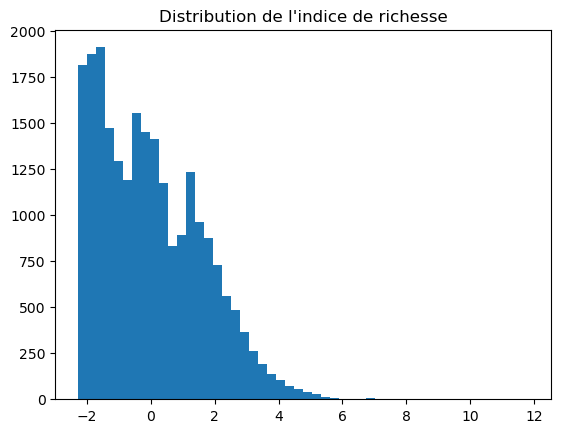

In [100]:
import matplotlib.pyplot as plt

#Histogramme de l'indice de richesse
plt.hist(base_menage['indice_riche'], bins=50)
plt.title("Distribution de l'indice de richesse")
plt.show()

In [ ]:
#Construire la variable pauvreté (1=ménag paauvre et 2= ménages non pauvres)
seuil = base_menage['indice_riche'].median()

base_menage['pauvre'] = (base_menage['indice_riche'] < seuil).astype(int)

base_menage['pauvre'].value_counts()

pauvre
0    11506
1    11505
Name: count, dtype: int64

In [105]:
#Variables explicatives pour la modélisation
features = [
'taille_menage',
'age_moyen',
'part_femmes',
'education_moyenne',
'age_chef',
'sexe_chef',
'nb_types_actifs',
'nb_total_actifs'
]

X = base_menage[features].copy()
y = base_menage['pauvre']

In [ ]:
from sklearn.model_selection import train_test_split

#Séparation en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#Petit diagnostic des données d'entraînement : Si une variable a, par exemple, 80 % de valeurs manquantes, il vaut souvent mieux la retirer du modèle.
print((X_train.isna().mean() * 100).sort_values(ascending=False))

education_moyenne    26.385267
nb_total_actifs       7.138201
nb_types_actifs       7.138201
taille_menage         0.000000
part_femmes           0.000000
age_moyen             0.000000
sexe_chef             0.000000
age_chef              0.000000
dtype: float64


In [115]:
import statsmodels.api as sm

from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

# 1. Remplacer les infinis par NaN
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

# 2. Imputation médiane
imputer = SimpleImputer(strategy='median')

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# 3. Logit
X_train_sm = sm.add_constant(X_train_imp)
X_test_sm = sm.add_constant(X_test_imp)

logit = sm.Logit(y_train, X_train_sm).fit()
pred_logit = (logit.predict(X_test_sm) > 0.5).astype(int)
accuracy_logit = accuracy_score(y_test, pred_logit)

# 4. Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train_imp, y_train)
pred_rf = rf.predict(X_test_imp)
accuracy_rf = accuracy_score(y_test, pred_rf)

# 5. Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_imp, y_train)
pred_gb = gb.predict(X_test_imp)
accuracy_gb = accuracy_score(y_test, pred_gb)

# 6. HistGradientBoosting
hgb = HistGradientBoostingClassifier(random_state=42)
hgb.fit(X_train, y_train)
pred_hgb = hgb.predict(X_test)
accuracy_hgb = accuracy_score(y_test, pred_hgb)

# 7. Comparaison
comparaison = pd.DataFrame({
    "Modele": ["Logit", "Random Forest", "Gradient Boosting", "HistGradientBoosting"],
    "Accuracy": [accuracy_logit, accuracy_rf, accuracy_gb, accuracy_hgb]
})

print(comparaison)

Optimization terminated successfully.
         Current function value: 0.543772
         Iterations 7
                 Modele  Accuracy
0                 Logit  0.723876
1         Random Forest  0.721703
2     Gradient Boosting  0.743211
3  HistGradientBoosting  0.742559


In [ ]:
from sklearn.metrics import confusion_matrix

#Matrice de confusion pour le modèle Gradient Boosting
print(confusion_matrix(y_test, pred_gb))

[[1479  778]
 [ 404 1942]]


In [ ]:
from sklearn.metrics import classification_report

#Rapport de classification pour le modèle Gradient Boosting
print(classification_report(y_test, pred_gb))

              precision    recall  f1-score   support

           0       0.79      0.66      0.71      2257
           1       0.71      0.83      0.77      2346

    accuracy                           0.74      4603
   macro avg       0.75      0.74      0.74      4603
weighted avg       0.75      0.74      0.74      4603



In [ ]:
#ROC AUC
from sklearn.metrics import roc_auc_score

proba_gb = gb.predict_proba(X_test_imp)[:,1]

auc = roc_auc_score(y_test, proba_gb)

print("AUC :", auc)

AUC : 0.8195455003869746


In [ ]:
#Analyse des variables importantes
importance = pd.Series(
    gb.feature_importances_,
    index=X_train_imp.columns
).sort_values(ascending=False)

print(importance.head(15))

nb_types_actifs      0.790416
nb_total_actifs      0.101800
age_chef             0.048306
education_moyenne    0.019276
age_moyen            0.013538
part_femmes          0.010471
sexe_chef            0.008910
taille_menage        0.007284
dtype: float64
